In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
df = pd.read_csv("/Users/athipongjindaphram/Documents/Python For Data Analyst/data_jobs.csv")
#Cleaning Date Column -> Type : Date time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_us = df[df["job_country"] == "United States"]

In [81]:
df_skills = df_us.explode("job_skills")

In [82]:
df_skill_count = df_skills.groupby(["job_skills", "job_title_short"]).size()
df_skill_count = df_skill_count.reset_index(name="skill_count")
df_skill_count.sort_values(by="skill_count", ascending=False, inplace=True)

In [83]:
job_titles = df_skill_count["job_title_short"].unique().tolist()
job_titles = sorted(job_titles[:3])

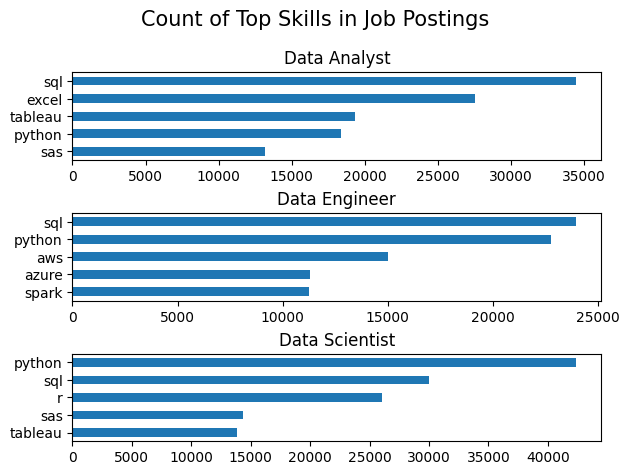

In [63]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_count[df_skill_count["job_title_short"] == job_title].head(5)
    df_plot.plot(kind="barh", x="job_skills", y="skill_count", ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)
fig.suptitle("Count of Top Skills in Job Postings", fontsize=15)
plt.tight_layout(h_pad=0.5)
plt.show()

In [54]:
df_job_title_count = df_us.groupby("job_title_short")["job_title"].count().to_frame()
df_job_title_count = df_job_title_count.rename(columns={'job_title': 'jobs_total'})

In [84]:
df_skill_perc = pd.merge(df_skill_count, df_job_title_count, how="left", on="job_title_short")
df_skill_perc["skill_percent"] = 100 * df_skill_perc["skill_count"] / df_skill_perc["jobs_total"]

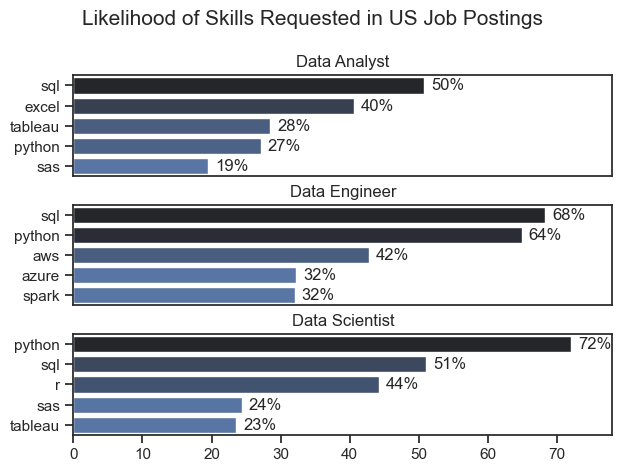

In [79]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style="ticks")

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc["job_title_short"] == job_title].head(5)
    sns.barplot(data=df_plot, x="skill_percent", y="job_skills", ax=ax[i], hue="skill_count", palette="dark:b_r")
    ax[i].set_title(job_title)
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
    ax[i].set_xlim(0, 78)
    ax[i].legend().set_visible(False)

    for n, v in enumerate(df_plot["skill_percent"]):
        ax[i].text(v + 1, n, f"{int(v)}%", va="center")

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
fig.suptitle("Likelihood of Skills Requested in US Job Postings", fontsize=15)
plt.tight_layout(h_pad=0.5)
plt.show()